In [2]:
# 데이터 확인하기 2025.11.19
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:

# describe 결과 불러오기
desc = pd.read_csv("../data/describe_summary.csv", index_col=0)

# 2. 원본 데이터 불러오기
df = pd.read_csv("../data/train.csv")

In [4]:
# 3. IQR 기반 이상치 기준 계산
Q1 = desc.loc["25%"]
Q3 = desc.loc["75%"]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [5]:
myCols = df.columns[2:74].to_list()

In [6]:
# 이상치 마스킹 (컬럼별로)
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

for col in df.select_dtypes(include="number").columns:
    if col in lower_bound.index:
        lb = lower_bound[col]
        ub = upper_bound[col]
        outlier_mask[col] = (df[col] < lb) | (df[col] > ub)

# 5. 이상치 기준 + 마스크를 outlier_bounds에 통합
outlier_bounds = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "LowerBound": lower_bound,
    "UpperBound": upper_bound,
    "OutlierCount": outlier_mask.sum()
})

print(outlier_bounds)


                                 Q1           Q3       IQR  LowerBound  \
ID                       38104.7500  113748.7500  75644.00 -75361.2500   
var3                         2.0000       2.0000      0.00      2.0000   
var15                       23.0000      40.0000     17.00     -2.5000   
imp_ent_var16_ult1           0.0000       0.0000      0.00      0.0000   
imp_op_var39_comer_ult1      0.0000       0.0000      0.00      0.0000   
...                             ...          ...       ...         ...   
saldo_medio_var44_hace3      0.0000       0.0000      0.00      0.0000   
saldo_medio_var44_ult1       0.0000       0.0000      0.00      0.0000   
saldo_medio_var44_ult3       0.0000       0.0000      0.00      0.0000   
var38                    67870.6125  118756.2525  50885.64  -8457.8475   
TARGET                       0.0000       0.0000      0.00      0.0000   

                          UpperBound  OutlierCount  
ID                       227214.7500             0  
var3 

In [7]:
outlier_bounds.to_csv('../data/outlier_bounds.csv')

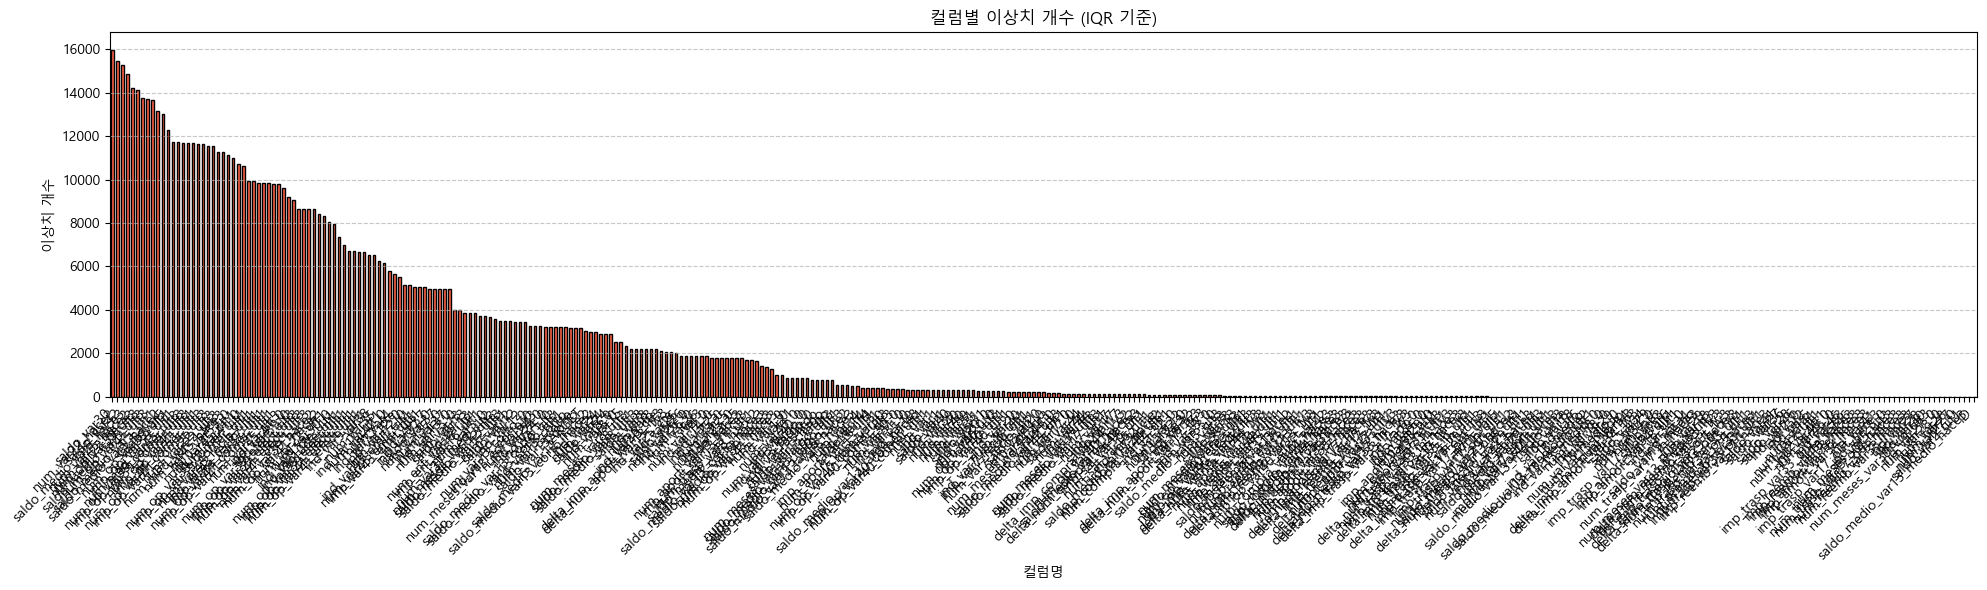

In [14]:
# 시각화
# outlier_series = outlier_bounds[outlier_bounds['OutlierCount']>500].sort_values('OutlierCount',ascending=False)
outlier_series = outlier_bounds['OutlierCount'].sort_values(ascending=False)

plt.figure(figsize=(20, 6))
outlier_series.plot(kind="bar", color="tomato", edgecolor="black")
plt.title("컬럼별 이상치 개수 (IQR 기준)")
plt.ylabel("이상치 개수")
plt.xlabel("컬럼명")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
outlier_series[outlier_series > 100]
# 0 보다 큰  331개
# 10 보다 큰 260개
# 50 보다 큰 221개
# 100 보다 큰 204개

saldo_var30                   15983
num_var22_hace2               15479
saldo_var42                   15281
saldo_medio_var5_hace3        14864
num_var45_hace2               14196
                              ...  
num_var17                       110
ind_var17                       110
saldo_var17                     110
delta_imp_compra_var44_1y3      102
num_op_var40_hace2              102
Name: OutlierCount, Length: 204, dtype: int64

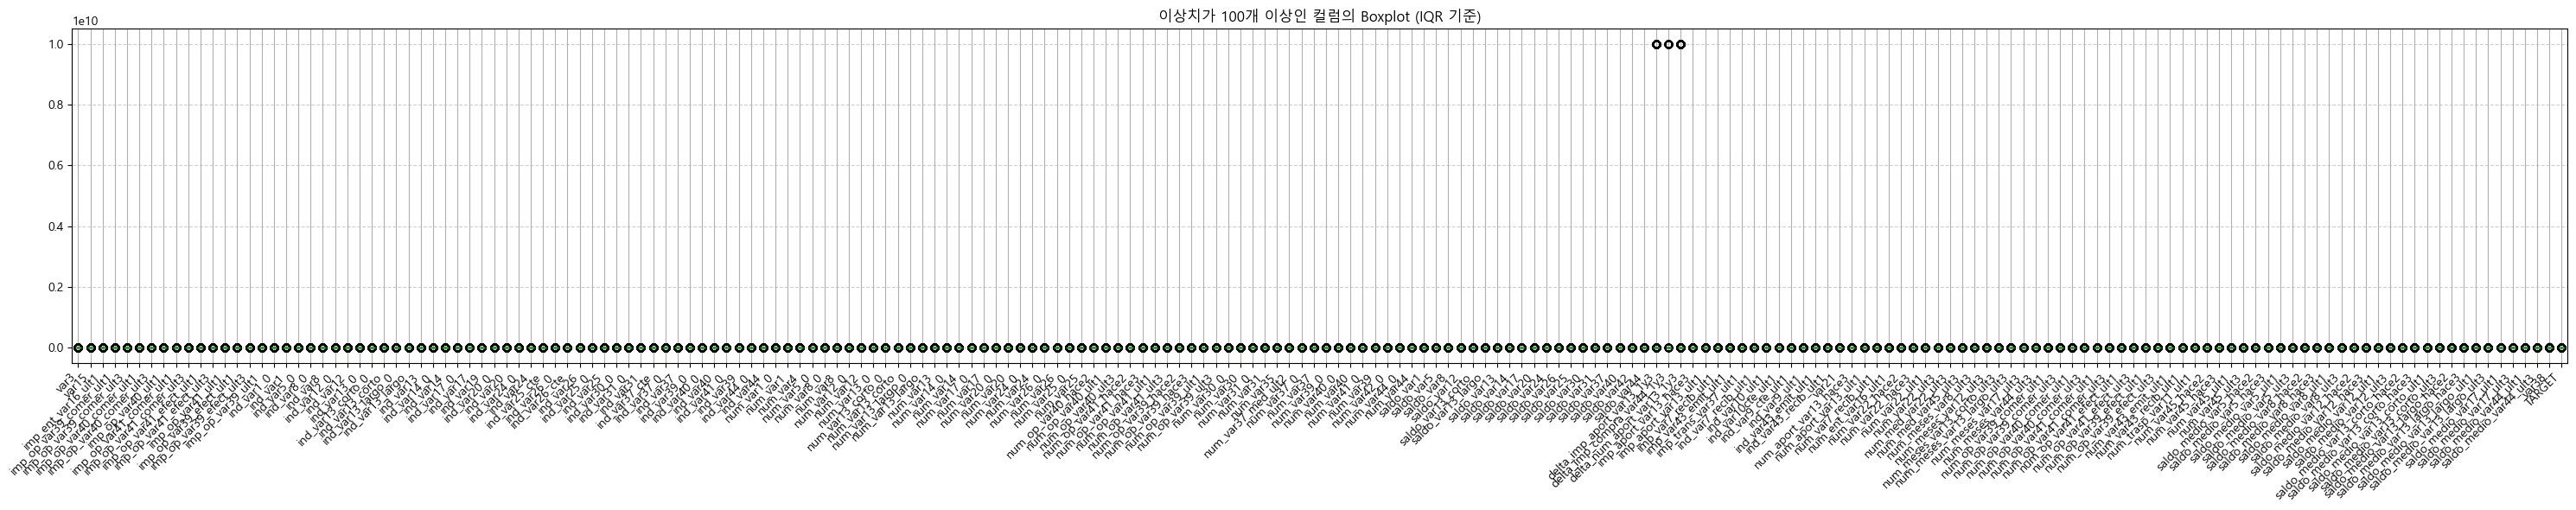

In [ ]:
# 5. 이상치가 n개 이상인 컬럼만 필터링
ncnt = 100
selected_cols = outlier_bounds[outlier_bounds["OutlierCount"] > ncnt].index.tolist()

# 6. Boxplot 시각화
plt.figure(figsize=(30, 6))
df[selected_cols].boxplot()
plt.title(f"이상치가 {ncnt}개 이상인 컬럼의 Boxplot (IQR 기준)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# 6. 10개씩 나눠서 Boxplot 시각화
# chunk_size = 5
# for i in range(0, len(selected_cols), chunk_size):
#     chunk = selected_cols[i:i + chunk_size]
    
#     plt.figure(figsize=(20, 6))
#     df[chunk].boxplot()
#     plt.title(f"이상치가 {ncnt}개 이상인 컬럼 Boxplot ({i+1}~{i+len(chunk)}번째)")
#     plt.xticks(rotation=45, ha="right")
#     plt.grid(True, axis="y", linestyle="--", alpha=0.6)
#     plt.tight_layout()
#     plt.show()


In [ ]:
# *_0 변수만 필터링
zero_vars = [col for col in df.columns if col.endswith('_0')]
zero_vars.append('TARGET')  # 타겟 포함

# 상관계수 계산
corr = df[zero_vars].corr(method='pearson')

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr[['TARGET']].sort_values(by='TARGET', ascending=False), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between *_0 variables and TARGET')
plt.show()


In [ ]:
# 방법 2: 요약 정보 (DataFrame으로)
print("\n" + "="*80)
print("전체 요약")
print("="*80)

allCols = df.columns[1:-1].to_list()

# 방법 2: 요약 정보 (DataFrame으로
summary_data = []
for col in allCols:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        mode_freq = df[col].value_counts().iloc[0] if len(df[col]) > 0 else 0
        
        summary_data.append({
            'ColumnName': col,  # 컬럼명
            'na_Sum': df[col].isna().sum(),  # 결측치_개수
            'nUnique': df[col].nunique(),  # 고유값_개수
            'mode': df[col].mode()[0] if len(df[col].mode()) > 0 else None,  # 최빈값
            'modeFreq': mode_freq,  # 최빈값_빈도
            'modeFreqRate': f"{(mode_freq / len(df) * 100):.2f}%",  # 최빈값_빈도_비율
            'zero_count': zero_count,  # 0값_개수
            'zero_count_rate': f"{(zero_count / len(df) * 100):.2f}%"  # 0값_비율
        })

summary_df = pd.DataFrame(summary_data)
sorted_summary_df = summary_df.sort_values('zero_count', ascending=False)
print(sorted_summary_df.to_string(index=False))
# sorted_summary_df.to_csv('../doc/data_summary.csv')
# allCols


전체 요약
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate
saldo_medio_var13_medio_hace3       0        1      0.000000     76020      100.00%       76020         100.00%
                     ind_var2       0        1      0.000000     76020      100.00%       76020         100.00%
        num_reemb_var33_hace3       0        1      0.000000     76020      100.00%       76020         100.00%
    num_trasp_var17_out_hace3       0        1      0.000000     76020      100.00%       76020         100.00%
    num_trasp_var33_out_hace3       0        1      0.000000     76020      100.00%       76020         100.00%
              saldo_var2_ult1       0        1      0.000000     76020      100.00%       76020         100.00%
                   ind_var2_0       0        1      0.000000     76020      100.00%       76020         100.00%
        imp_amort_var34_hace3       0        1      0.000000     76020      100.00%       76020  

In [ ]:
sorted_summary_df.to_excel('../data/annomaly_summary.xlsx', )


                               컬럼별 값 분포 시각화 (5개씩)                               


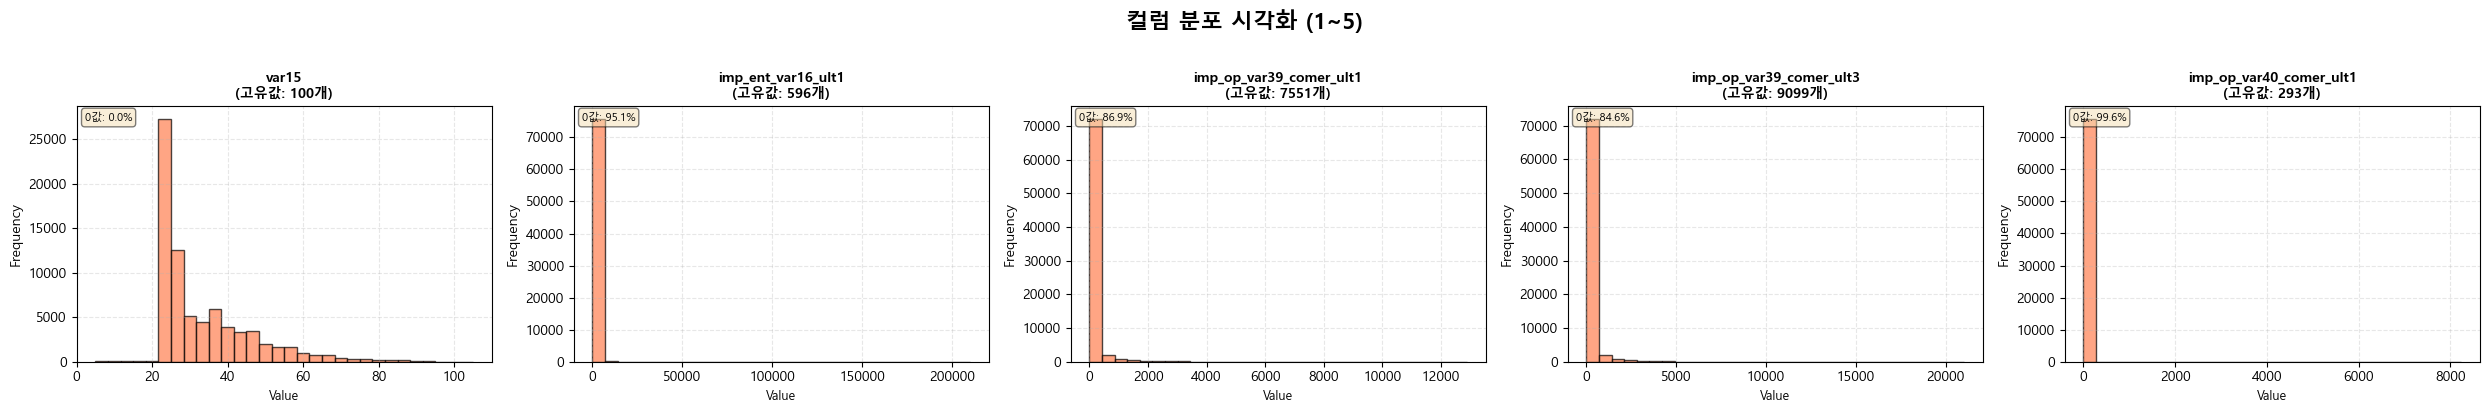


그룹 1 완료: ['var15', 'imp_ent_var16_ult1', 'imp_op_var39_comer_ult1', 'imp_op_var39_comer_ult3', 'imp_op_var40_comer_ult1']
--------------------------------------------------------------------------------


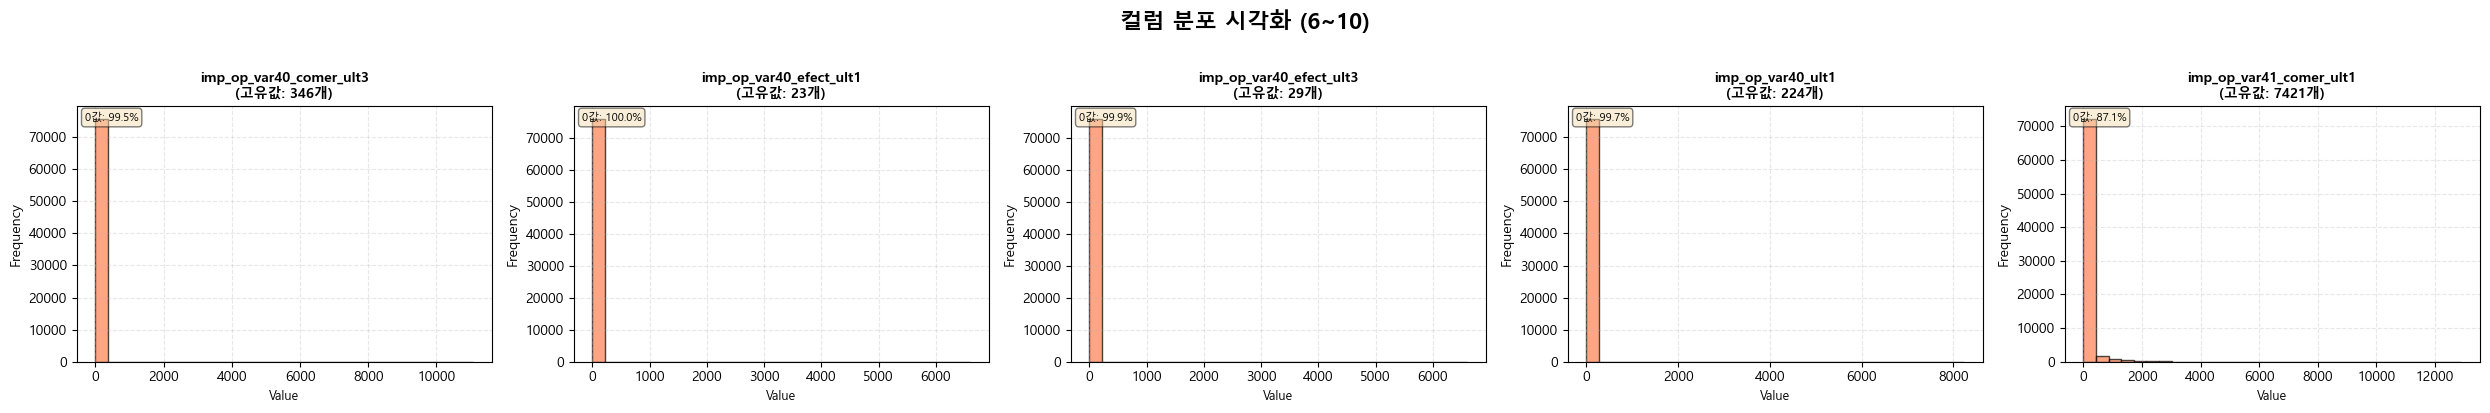


그룹 2 완료: ['imp_op_var40_comer_ult3', 'imp_op_var40_efect_ult1', 'imp_op_var40_efect_ult3', 'imp_op_var40_ult1', 'imp_op_var41_comer_ult1']
--------------------------------------------------------------------------------


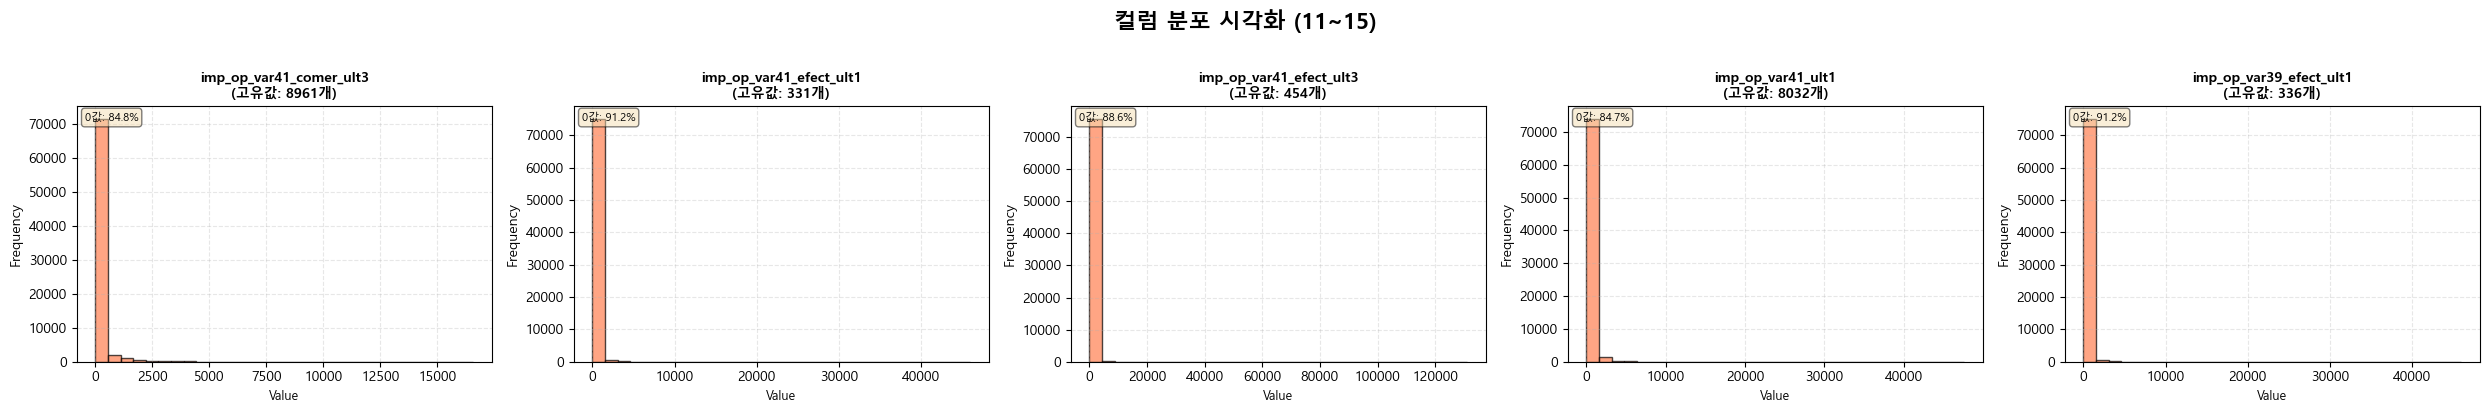


그룹 3 완료: ['imp_op_var41_comer_ult3', 'imp_op_var41_efect_ult1', 'imp_op_var41_efect_ult3', 'imp_op_var41_ult1', 'imp_op_var39_efect_ult1']
--------------------------------------------------------------------------------


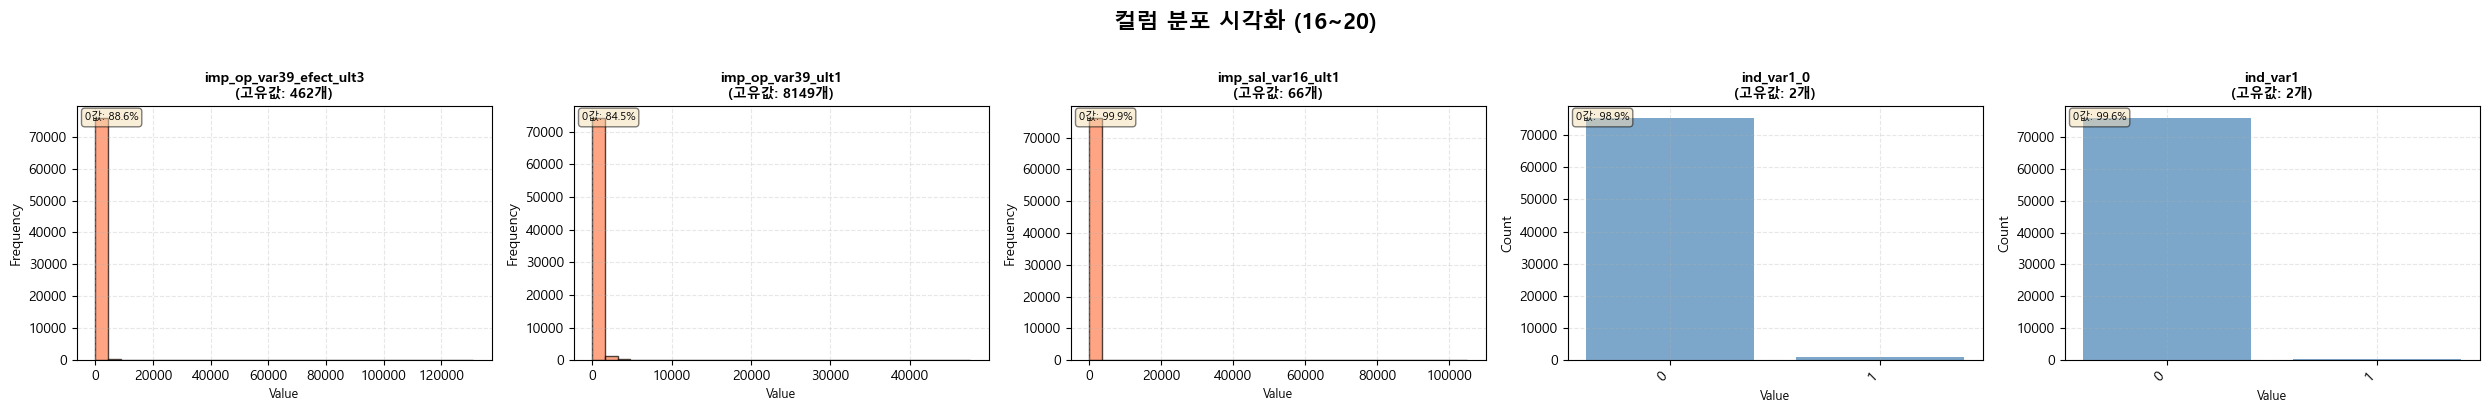


그룹 4 완료: ['imp_op_var39_efect_ult3', 'imp_op_var39_ult1', 'imp_sal_var16_ult1', 'ind_var1_0', 'ind_var1']
--------------------------------------------------------------------------------


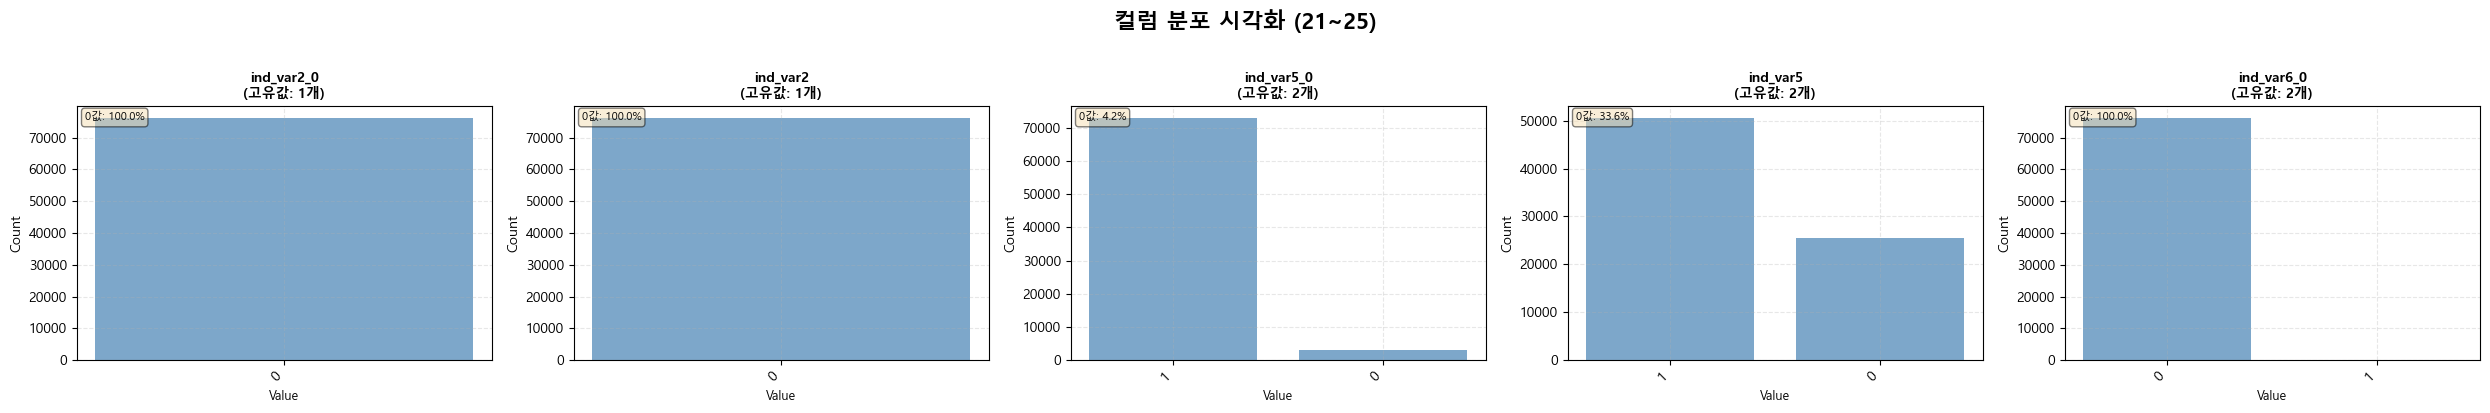


그룹 5 완료: ['ind_var2_0', 'ind_var2', 'ind_var5_0', 'ind_var5', 'ind_var6_0']
--------------------------------------------------------------------------------


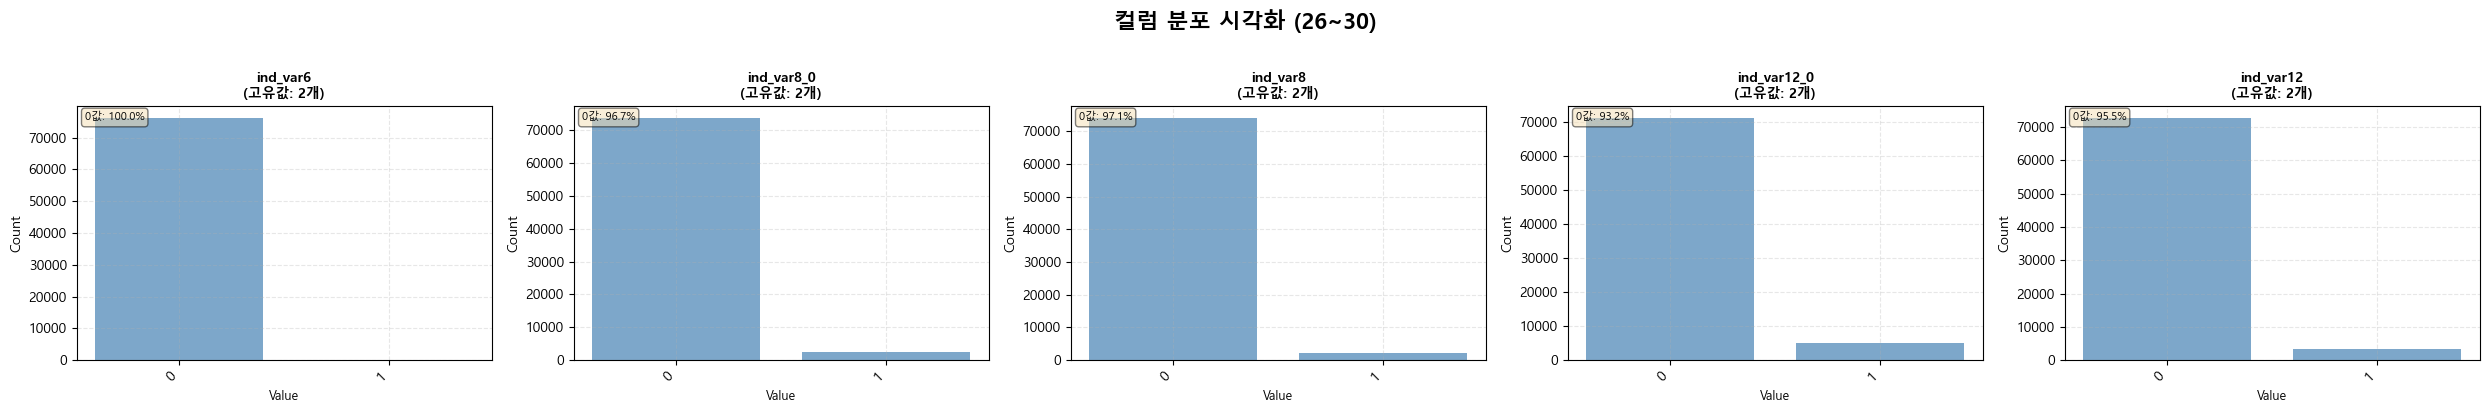


그룹 6 완료: ['ind_var6', 'ind_var8_0', 'ind_var8', 'ind_var12_0', 'ind_var12']
--------------------------------------------------------------------------------


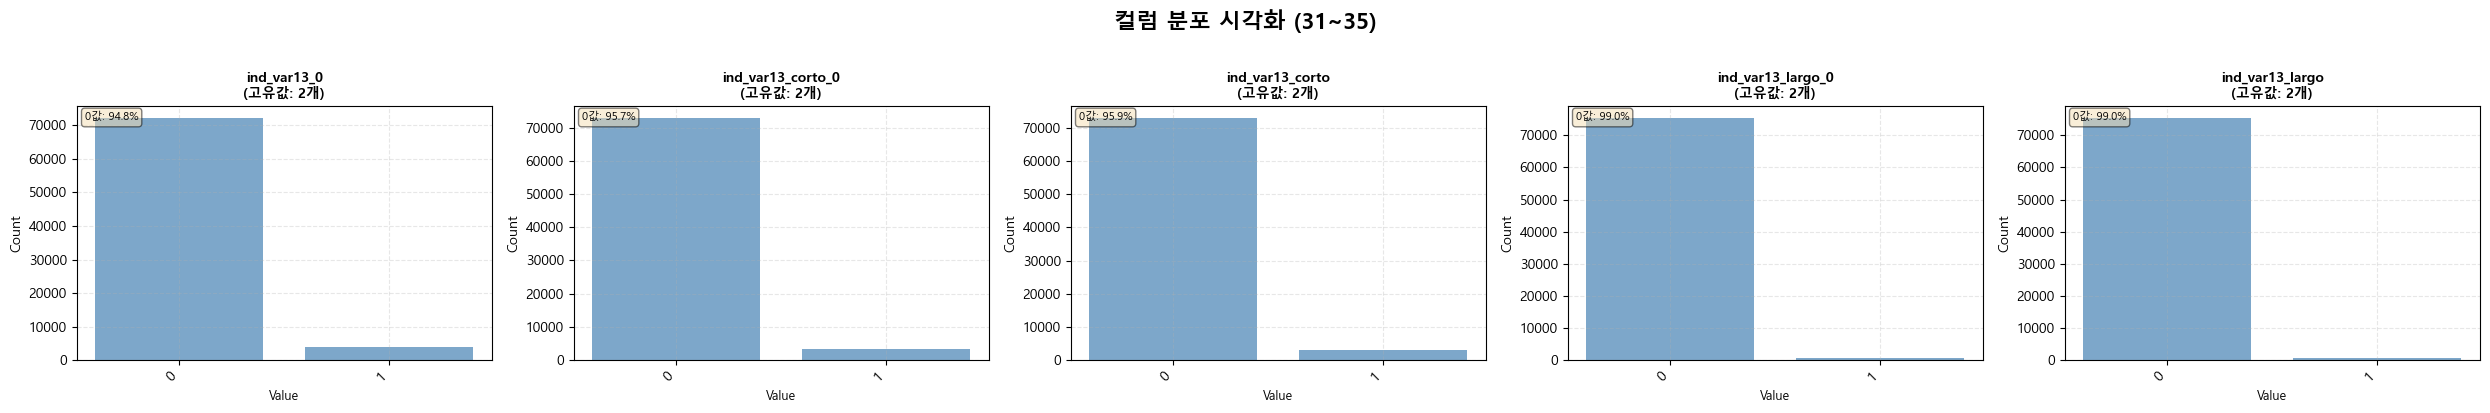


그룹 7 완료: ['ind_var13_0', 'ind_var13_corto_0', 'ind_var13_corto', 'ind_var13_largo_0', 'ind_var13_largo']
--------------------------------------------------------------------------------


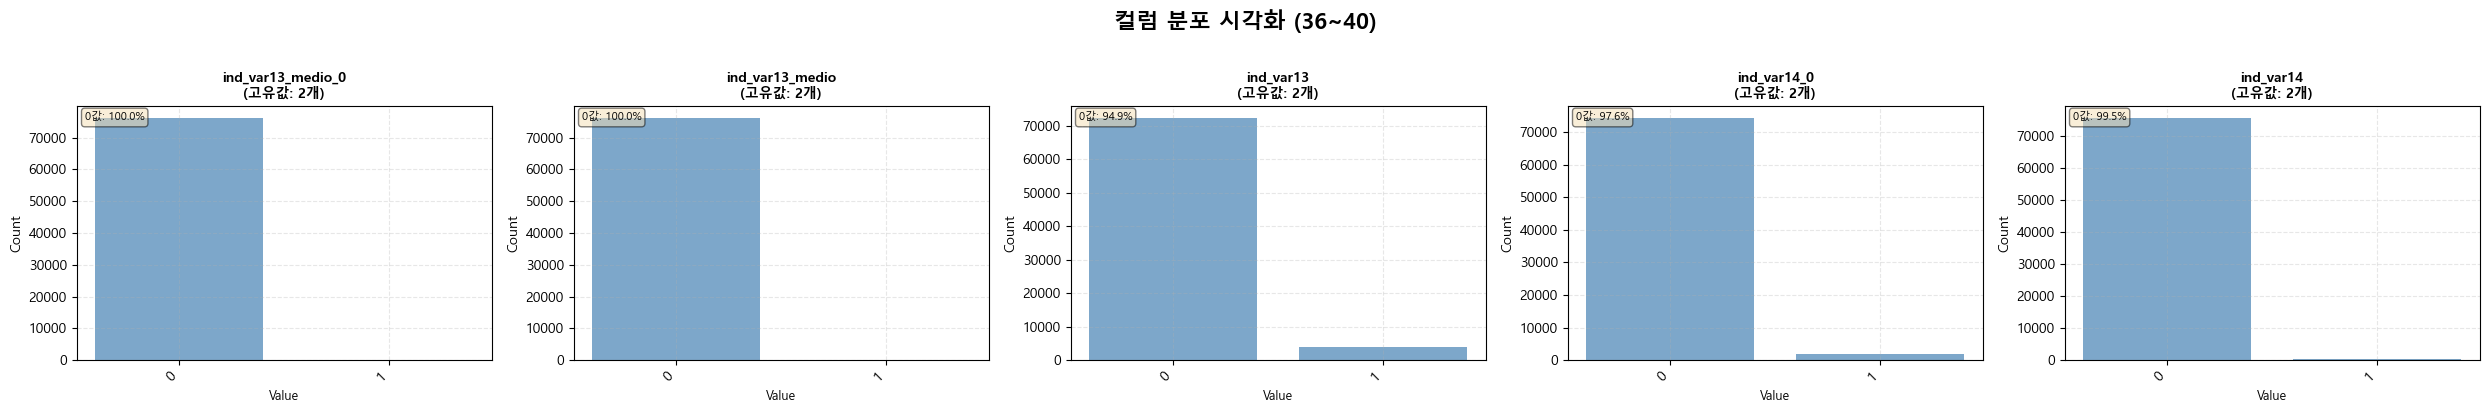


그룹 8 완료: ['ind_var13_medio_0', 'ind_var13_medio', 'ind_var13', 'ind_var14_0', 'ind_var14']
--------------------------------------------------------------------------------


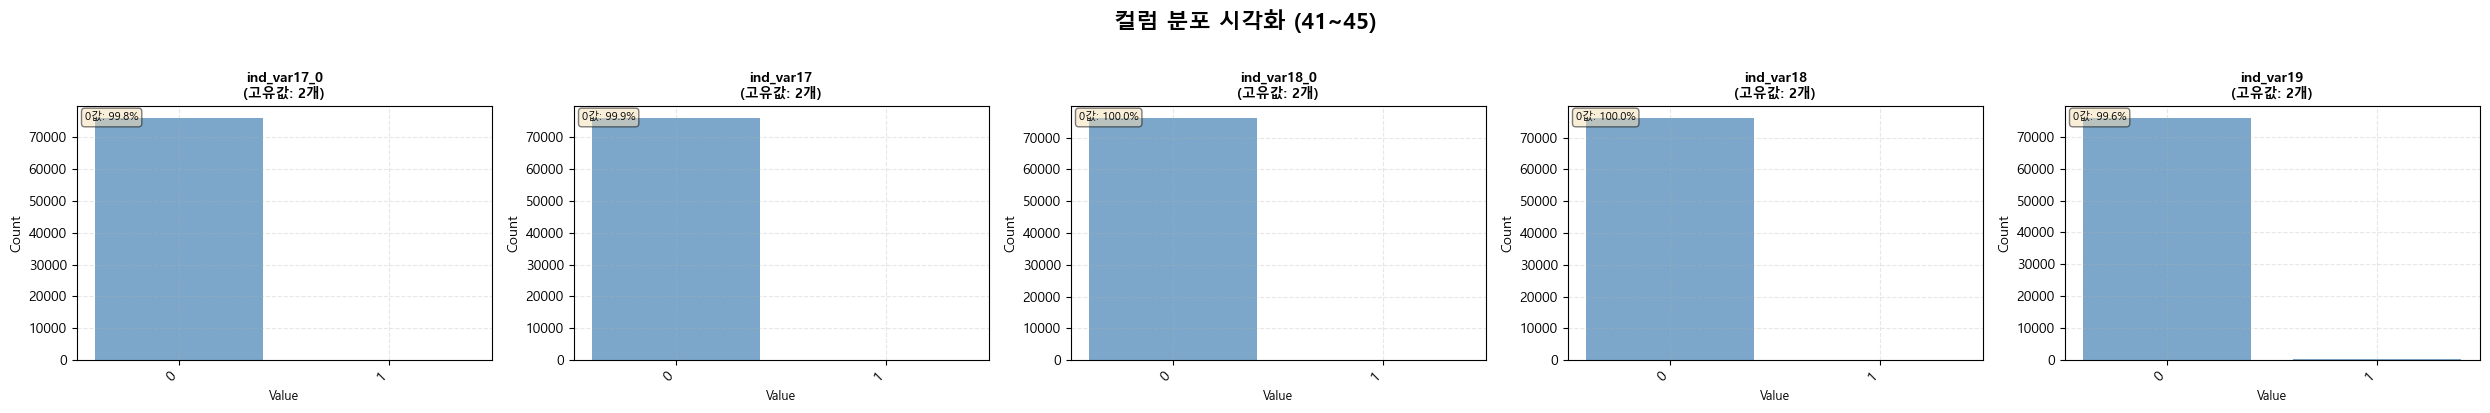


그룹 9 완료: ['ind_var17_0', 'ind_var17', 'ind_var18_0', 'ind_var18', 'ind_var19']
--------------------------------------------------------------------------------


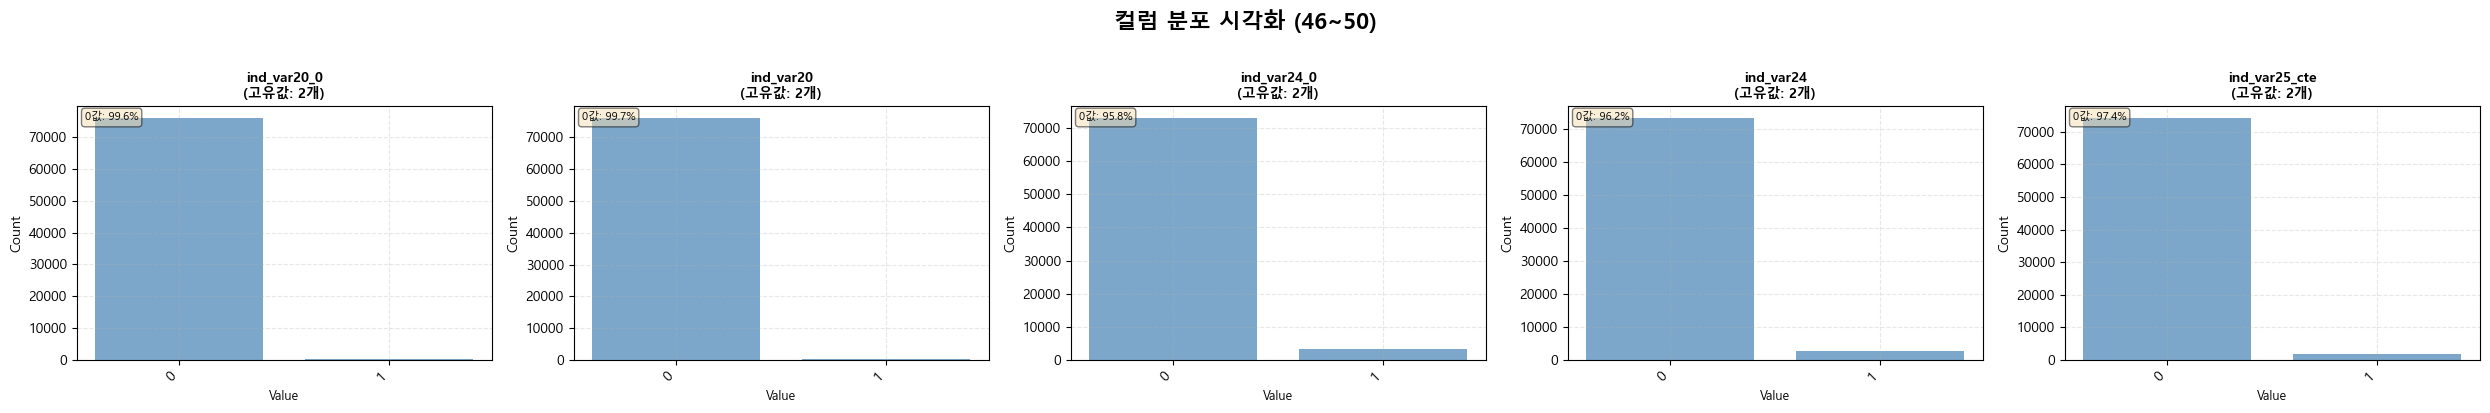


그룹 10 완료: ['ind_var20_0', 'ind_var20', 'ind_var24_0', 'ind_var24', 'ind_var25_cte']
--------------------------------------------------------------------------------


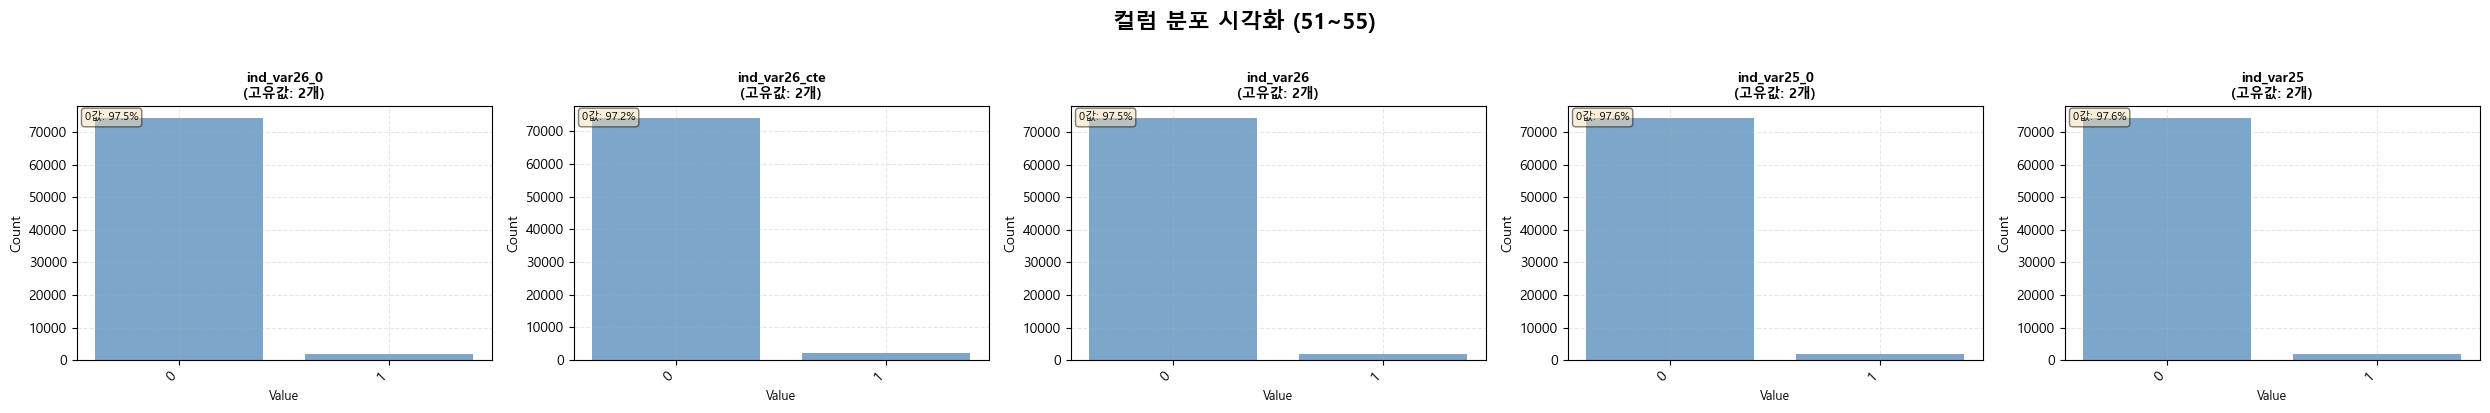


그룹 11 완료: ['ind_var26_0', 'ind_var26_cte', 'ind_var26', 'ind_var25_0', 'ind_var25']
--------------------------------------------------------------------------------


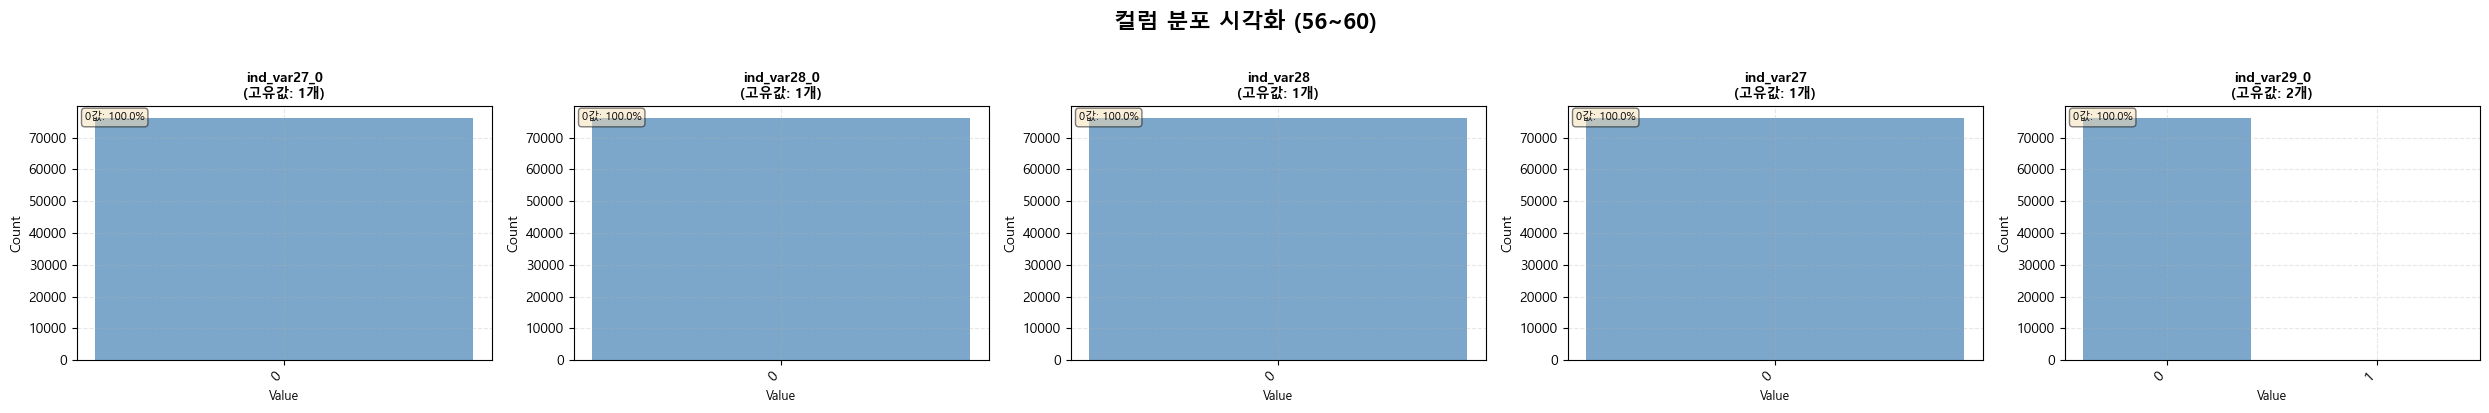


그룹 12 완료: ['ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var29_0']
--------------------------------------------------------------------------------


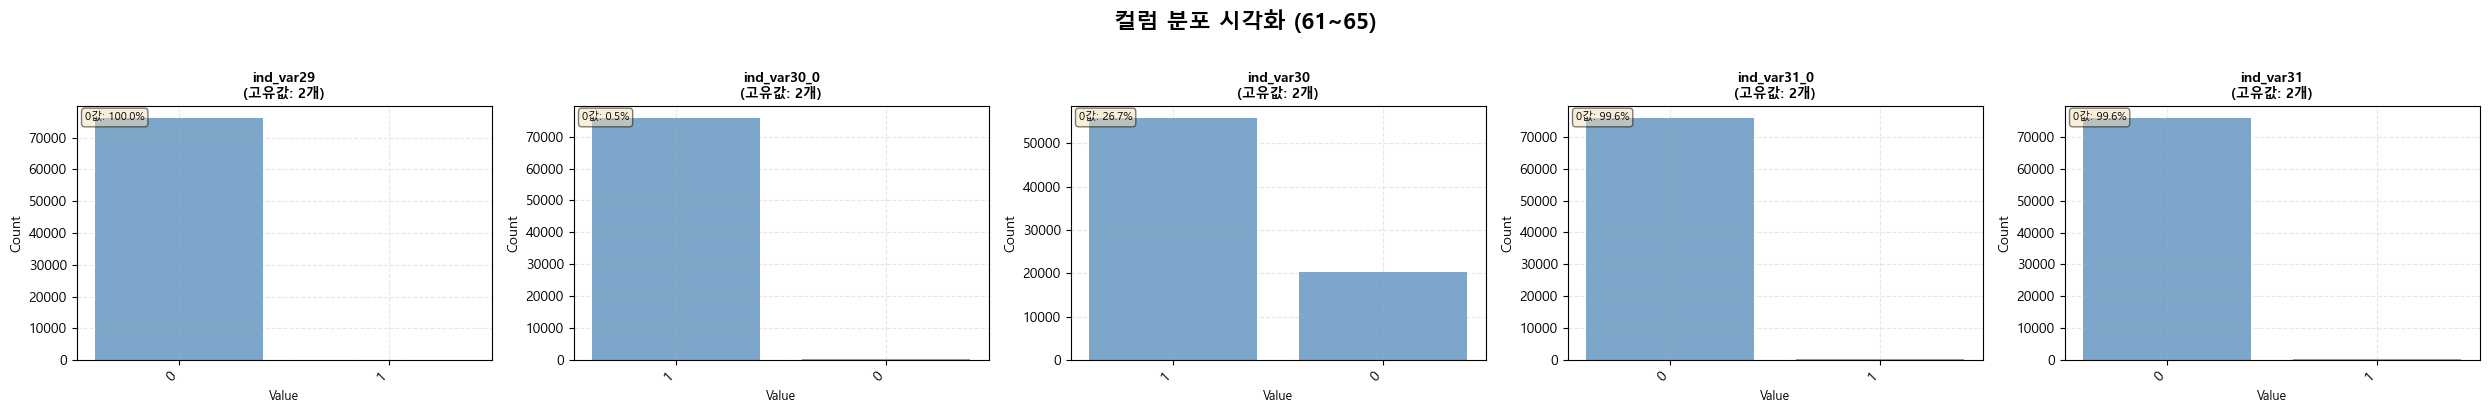


그룹 13 완료: ['ind_var29', 'ind_var30_0', 'ind_var30', 'ind_var31_0', 'ind_var31']
--------------------------------------------------------------------------------


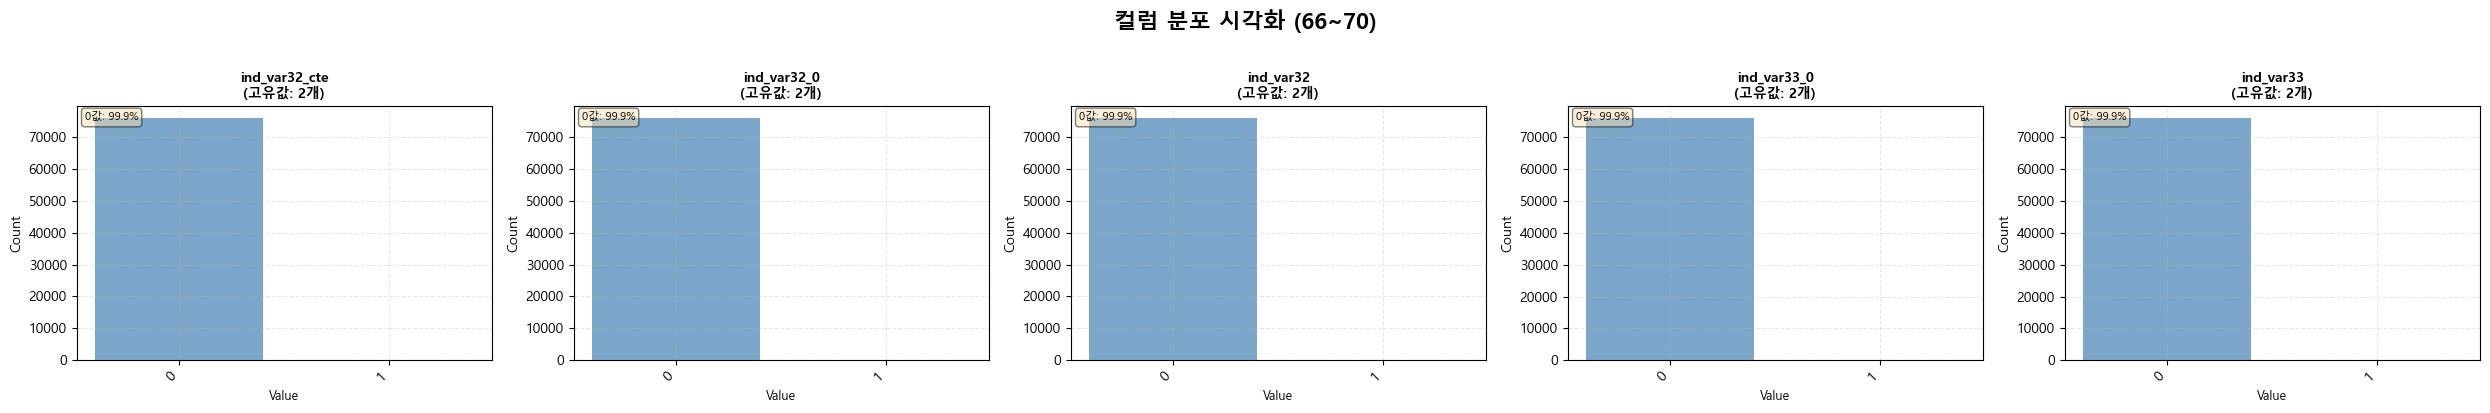


그룹 14 완료: ['ind_var32_cte', 'ind_var32_0', 'ind_var32', 'ind_var33_0', 'ind_var33']
--------------------------------------------------------------------------------


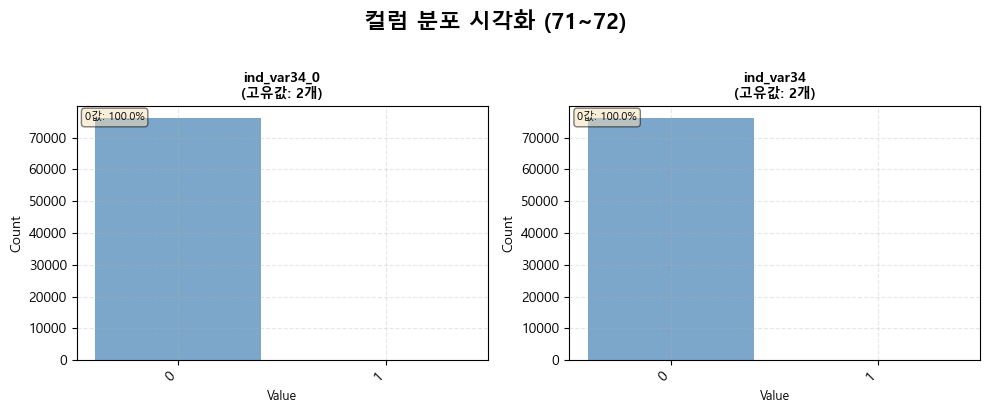


그룹 15 완료: ['ind_var34_0', 'ind_var34']
--------------------------------------------------------------------------------


In [ ]:
# 5개씩 컬럼 시각화
print(f"\n{'='*80}")
print(f"{'컬럼별 값 분포 시각화 (5개씩)':^80}")
print(f"{'='*80}")

# myCols를 5개씩 나누기
cols_per_plot = 5
num_plots = int(np.ceil(len(myCols) / cols_per_plot))

for plot_idx in range(num_plots):
    # 현재 그룹의 컬럼들
    start_idx = plot_idx * cols_per_plot
    end_idx = min((plot_idx + 1) * cols_per_plot, len(myCols))
    current_cols = myCols[start_idx:end_idx]
    
    # 실제 존재하는 컬럼만 필터링
    existing_cols = [col for col in current_cols if col in df.columns]
    
    if not existing_cols:
        continue
    
    # 서브플롯 생성
    fig, axes = plt.subplots(1, len(existing_cols), figsize=(5*len(existing_cols), 4))
    
    # axes가 단일 객체인 경우 리스트로 변환
    if len(existing_cols) == 1:
        axes = [axes]
    
    fig.suptitle(f'컬럼 분포 시각화 ({start_idx+1}~{start_idx+len(existing_cols)})', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # 각 컬럼별 히스토그램
    for idx, col in enumerate(existing_cols):
        ax = axes[idx]
        
        # 고유값이 너무 많으면 히스토그램, 적으면 countplot
        n_unique = df[col].nunique()
        
        if n_unique <= 20:  # 고유값이 20개 이하면 countplot
            value_counts = df[col].value_counts().head(10)
            ax.bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.7)
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
            ax.set_ylabel('Count', fontsize=10)
        else:  # 고유값이 많으면 히스토그램
            df[col].hist(bins=30, ax=ax, color='coral', alpha=0.7, edgecolor='black')
            ax.set_ylabel('Frequency', fontsize=10)
        
        ax.set_title(f'{col}\n(고유값: {n_unique}개)', fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # 0값 비율 표시
        zero_rate = (df[col] == 0).sum() / len(df) * 100
        ax.text(0.02, 0.98, f'0값: {zero_rate:.1f}%', 
                transform=ax.transAxes, 
                fontsize=8, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    print(f"\n그룹 {plot_idx+1} 완료: {existing_cols}")
    print(f"{'-'*80}")